In [47]:
import sys
import gc
import os
import re
from pathlib import Path

sys.path.append("../../src/")

import torch
import torch.nn as nn
from torch import topk
import matplotlib.pyplot as plt
import numpy as np
from sklearn.decomposition import PCA
from scipy.stats import gaussian_kde
import seaborn as sns

from adabmDCA.fasta import get_tokens, write_fasta, import_from_fasta, encode_sequence
from adabmDCA.utils import get_device, get_dtype
from adabmDCA.dataset import DatasetDCA
from adabmDCA.functional import one_hot
from adabmDCA.statmech import compute_energy
from adabmDCA.io import load_params

import arDCA_paths
from arDCA_paths import arDCA_paths

device = get_device("cpu")
device2 = get_device("cuda")
dtype = get_dtype("float32")

plt.rcParams.update({
    "text.usetex": True,
})

print("Libraries loaded successfully!")

Running on CPU
Running on NVIDIA RTX A4000
Libraries loaded successfully!


# Helper Functions

### Sampling Functions

Define `predict_naive` (direct-path heuristic), `predict` (arDCA stochastic decoding), `predict_cond_start` and `predict_cond_end` (conditional predictions from the start or end endpoint). All functions fill the third segment of a sequence triplet `(S_start, S_mid, S_end)`.

In [48]:
def predict_naive(data):
    X = one_hot(data.clone(), num_classes=21).to(dtype=dtype)
    B, L, q = X.shape
    l = L // 3
    first, second = X[:, :l, :], X[:, l:2*l, :]
    third = first.clone()
    mask_equal = (first == second).all(dim=2)
    rand = torch.rand(B, l, device=X.device)
    mask_replace = (~mask_equal) & (rand >= 0.5)
    third[mask_replace] = second[mask_replace]
    X[:, 2*l:3*l, :] = third
    return X.argmax(dim=-1)

def predict(data, model, ML=False, beta=1, device="cpu"):
    with torch.no_grad():
        model.to(device)
        X = one_hot(data.clone(), num_classes=21).to(dtype=dtype).to(device)
        L = X.shape[1]
        l = model.L // 3
        for i in range(L - l, L):
            prob = model.forward(X[:, :i, :], beta=beta)
            sample = prob.argmax(dim=1) if ML else torch.multinomial(prob, num_samples=1).squeeze()
            X[:, i] = nn.functional.one_hot(sample, model.q).to(dtype=model.h.dtype)
        model.to("cpu")
        return X.argmax(dim=-1).to("cpu")


def predict_cond_start(data, model, ML=False, beta=1, device="cpu"):
    """Predict using arDCA by sequentially filling the last third of the sequence."""
    torch.no_grad()
    model.to(device)
    # X = data.clone().to(device)
    L = data.shape[1]
    l = L // 3
    X_end = one_hot(data, num_classes=21)[:, 2*l:, :].clone().to(dtype=dtype).to(device)
    X_use = one_hot(data, num_classes=21)[:, :2*l, :].clone().to(dtype=dtype).to(device)
    for i in range(l, 2*l):
        prob = model.forward(X_use[:, :i, :], beta=beta)
        sample = prob.argmax(dim=1) if ML else torch.multinomial(prob, num_samples=1).squeeze()
        X_use[:, i] = nn.functional.one_hot(sample, model.q).to(dtype=model.h.dtype)
    model.to("cpu")
    X = torch.cat((X_use[:, :l], X_end, X_use[:, l:]), dim=1)
    return X.argmax(dim=-1).to("cpu")

def predict_cond_end(data, model, ML=False, beta=1, device="cpu"):
    """Predict using arDCA by sequentially filling the last third of the sequence."""
    torch.no_grad()
    model.to(device)
    L = data.shape[1]
    l = L // 3
    X_start = one_hot(data, num_classes=21)[:, :l, :].clone().to(dtype=dtype).to(device)
    X_use = one_hot(data, num_classes=21)[:, l:, :].clone().to(dtype=dtype).to(device)
    for i in range(l, 2*l):
        prob = model.forward(X_use[:, :i, :], beta=beta)
        sample = prob.argmax(dim=1) if ML else torch.multinomial(prob, num_samples=1).squeeze()
        X_use[:, i] = nn.functional.one_hot(sample, model.q).to(dtype=model.h.dtype)
    model.to("cpu")
    X = torch.cat((X_start, X_use), dim=1)
    return X.argmax(dim=-1).to("cpu")

### Accuracy Functions

Define `compute_accuracy`, which returns per-sequence reconstruction accuracy for the third segment (fraction of correctly predicted residues).

In [49]:
def compute_accuracy(data, prediction):
    l = data.shape[1] // 3
    third = data[:, 2*l:3*l, :].argmax(dim=-1)
    third_pred = prediction[:, 2*l:3*l, :].argmax(dim=-1)
    return (third == third_pred).float().sum(dim=-1) / l

# Data Loading

### Protein Family Selection

Choose the protein family and configure all input/output paths: data directory, CDE arrays, MSA file, bmDCA model, trained arDCA models, and output directory.

In [92]:
protein_family = "PF00072"
# use_1cond = True
best = ""
patience = "patience5/"
percentile = 0.5

if protein_family == "Chorismate Mutase":
    data_path = "../generated_data/CM"
    cde_path = "../generated_data/CM/full_cde_test"
    MSA_path = "../MSAs/CM_130530_MC.fasta"
    original_model_path = "../evolution_bmDCA_model/CM/params.dat"
    t = 0
    model_paths = f"../models_train_val/CM/{patience}"
    model_1cond_path = f"../models_train_val/CM/{patience}1cond/"
   
    reg = "rJ1e-3_rH1e-5" # "long_run_rJ1e-3_rH1e-5"
    
    if percentile == 0:
        output_path = f"../immagini_paper/CM/{patience}compare_metrics/{best}_{reg}/"
    else: 
        output_path = f"../immagini_paper/CM/{patience}compare_metrics/{best}_{reg}_percentile{percentile}/"



elif protein_family == "PF00072":
    data_path = "../generated_data/PF00072"
    cde_path = "../generated_data/PF00072/full_cde_test"
    MSA_path = "../MSAs/PF00072.fasta"
    original_model_path = "../evolution_bmDCA_model/PF00072/params.dat"
    t = 0
    model_paths = f"../models_train_val/PF00072/{patience}"
    model_1cond_path = f"../models_train_val/PF00072/{patience}1cond/"
    reg = "rJ1e-3_rH1e-5" # "long_run_rJ1e-3_rH1e-5"
    if percentile == 0:
        output_path = f"../immagini_paper/PF00072/{patience}compare_metrics/{best}_{reg}/"
    else:
        output_path = f"../immagini_paper/PF00072/{patience}compare_metrics/{best}_{reg}_percentile{percentile}/"


elif protein_family == "betalactamase":
    data_path = "../generated_data/betalactamase"
    cde_path = "../generated_data/betalactamase/full_cde_test"
    MSA_path = "../MSAs/betalactamase_nodupl_natural_noflankgaps.fa"
    original_model_path = "../evolution_bmDCA_model/betalactamase/params.dat"
    t = 0
    model_paths = f"../models_train_val/betalactamase/{patience}"
    model_1cond_path = f"../models_train_val/betalactamase/{patience}1cond/"
    reg = "rJ1e-3_rH1e-5" # "long_run_rJ1e-3_rH1e-5"

    if percentile == 0:
        output_path = f"../immagini_paper/betalactamase/{patience}compare_metrics/{best}_{reg}/"
    else:
        output_path = f"../immagini_paper/betalactamase/{patience}compare_metrics/{best}_{reg}_percentile{percentile}/"

else:
    raise ValueError(f"Unknown protein family: {protein_family}")


os.makedirs(output_path, exist_ok=True)
print(f"Output path created/verified: {output_path}")


Output path created/verified: ../immagini_paper/CM/patience5/compare_metrics/_rJ1e-3_rH1e-5_percentile0.5/


In [93]:
data_type = "ACDEFGHIKLMNPQRSTVWY-"
tokens = get_tokens(data_type)

timescales = ["10e1", "10e2", "10e3", "10e4", "10e5", "10e6"] 
n_seqs = 20_000

data_files = [
    f"{data_path}/10e1_test.fasta",
    f"{data_path}/10e2_test.fasta",
    f"{data_path}/10e3_test.fasta",
    f"{data_path}/10e4_test.fasta",
    f"{data_path}/10e5_test.fasta",
    f"{data_path}/10e6_test.fasta",
]

datasets = {}
dataset_indices = {}
for t, path in zip(timescales, data_files):
    ds = DatasetDCA(path_data=path, alphabet=data_type, device=device, dtype=dtype, no_reweighting=True)
    # indices = torch.randperm(ds.data.shape[0])[:n_seqs]
    # dataset_indices[t] = indices.cpu()
    datasets[t] = ds.data[:n_seqs] #.argmax(dim=-1)
    del ds
    gc.collect()

print(f"Loaded {len(datasets)} datasets with {n_seqs} sequences each")


Multi-sequence alignment imported: M = 29943, L = 288, q = 21, M_eff = 29943.
Multi-sequence alignment imported: M = 30000, L = 288, q = 21, M_eff = 30000.
Multi-sequence alignment imported: M = 30000, L = 288, q = 21, M_eff = 30000.
Multi-sequence alignment imported: M = 30000, L = 288, q = 21, M_eff = 30000.
Multi-sequence alignment imported: M = 30000, L = 288, q = 21, M_eff = 30000.
Multi-sequence alignment imported: M = 20000, L = 288, q = 21, M_eff = 20000.
Loaded 6 datasets with 20000 sequences each


In [94]:
datasets_oh = {
    key: one_hot(data, num_classes=21).to(dtype=dtype)
    for key, data in datasets.items()
}

# Model Loading

In [95]:
q = 21

headers, msa_enc_nat = import_from_fasta(MSA_path, tokens=tokens, filter_sequences=True)
msa_oh_nat = one_hot(torch.tensor(msa_enc_nat, device=device, dtype=torch.int32), num_classes=q).to(dtype)

M, L3 = datasets[timescales[0]].shape
L = L3 // 3

original_tokens = get_tokens("ACDEFGHIKLMNPQRSTVWY-")
original_model = load_params(original_model_path, tokens=original_tokens, device=device, dtype=dtype)

print(f"Loaded natural MSA: {msa_oh_nat.shape[0]} sequences, L={L}")

Unknown token found: removing sequence gi|297170754|gb|ADI21776.1| hypothetical protein [uncultured gamma proteobacterium HF0130_22O14]
Loaded natural MSA: 1258 sequences, L=96


### Conservation-Diversity Entropy (CDE)

Define `load_cde_dict` to load precomputed per-sequence CDE arrays from disk, aligned with the test datasets. Load the CDE arrays for the initial segment (`CDE_0`, `CDE_0_mean`).

### arDCA Models

Load one trained arDCA model per evolutionary timescale. These models reconstruct the third segment conditioned on the first two.

In [96]:
models = {}
for t in timescales:
    path_params = model_paths
    params = torch.load(model_paths + f"{t}_{reg}/params{best}.pth", map_location='cpu')
    params['entropic_order'] = torch.arange(0, L3, dtype=torch.long, device='cpu')
    params['inverse_entropic_order'] = torch.arange(0, L3, dtype=torch.long, device='cpu')
    model = arDCA_paths(L=L3, q=q).to(device='cpu', dtype=dtype)
    model.load_state_dict(params, strict=False)
    models[t] = model

print(f"Loaded {len(models)} arDCA models")

arDCA model initialized with third
arDCA model initialized with third
arDCA model initialized with third
arDCA model initialized with third
arDCA model initialized with third
arDCA model initialized with third
Loaded 6 arDCA models


### Conditional (1-cond) Models

*(Disabled — set `use_1cond = True` to activate.)* Load secondary arDCA models for conditional predictions from the start or end endpoint.

# Predictions

Generate reconstructions of the third segment using three strategies: naive direct-path heuristic, arDCA stochastic sampling, and arDCA ML greedy decoding. Convert all predictions to one-hot encoding.

In [97]:
Temperature = 1.0
beta = 1 / Temperature

print("Predicting with naive...")
predicted_naive = {key: predict_naive(datasets[key]) for key in timescales}

print("Predicting with arDCA (sampling)...")
predicted = {key: predict(data, models[key], ML=False, beta=beta, device=device2) for key, data in datasets.items()}

print("Predicting with arDCA (ML)...")
predictedML = {key: predict(data, models[key], ML=True, beta=beta, device=device2) for key, data in datasets.items()}


predicted_naive_oh = {
    key: one_hot(data, num_classes=21).to(dtype=dtype)
    for key, data in predicted_naive.items()
}
predicted_oh = {
    key: one_hot(data, num_classes=21).to(dtype=dtype)
    for key, data in predicted.items()
}
predictedML_oh = {
    key: one_hot(data, num_classes=21).to(dtype=dtype)
    for key, data in predictedML.items()
}


Predicting with naive...
Predicting with arDCA (sampling)...
Predicting with arDCA (ML)...


# Distance Metrics

Compute pairwise Hamming distances between segments `(S_start, S_mid)`, `(S_mid, S_end)`, and `(S_start, S_end)` for both the ground-truth data and each prediction method.

In [98]:
def compute_distance(sample):
    l = sample.shape[1] // 3
    a, b, c = sample.split(l, dim=1)
    return (a != c).sum(dim=1), (b != c).sum(dim=1), (a != b).sum(dim=1)

In [99]:
distance_data = {key: torch.stack(compute_distance(data), dim=1) for key, data in datasets.items()}
distance_mdl = {key: torch.stack(compute_distance(predicted[key]), dim=1) for key in timescales}
distance_mdl_ML = {key: torch.stack(compute_distance(predictedML[key]), dim=1) for key in timescales}
distance_naive = {key: torch.stack(compute_distance(predicted_naive[key]), dim=1) for key in timescales}

print("Distance computations complete!")

Distance computations complete!


# Energy Analysis

Compute the bmDCA energy of the predicted and ground-truth third segments using the reference model. Energies quantify how thermodynamically plausible each predicted sequence is.

In [100]:
energies_data       = {t: compute_energy(data[:, 2*L:, :],   original_model) for t, data in datasets_oh.items()}
energies_data_start = {t: compute_energy(data[:, 0:L, :],    original_model) for t, data in datasets_oh.items()}
energies_data_end   = {t: compute_energy(data[:, L:2*L:, :], original_model) for t, data in datasets_oh.items()}

energies_naive = {t: compute_energy(data[:, 2*L:, :], original_model) for t, data in predicted_naive_oh.items()}
energies_model = {t: compute_energy(data[:, 2*L:, :], original_model) for t, data in predicted_oh.items()}
energies_ML    = {t: compute_energy(data[:, 2*L:, :], original_model) for t, data in predictedML_oh.items()}

energies_nat = compute_energy(msa_oh_nat, original_model) 

# Reconstruction Accuracy

Compute per-sequence ML accuracy for naive, stochastic, and ML predictions across all timescales.

In [101]:
acc_naive = {key: compute_accuracy(datasets_oh[key], predicted_naive_oh[key]) for key in timescales}
acc_mdl = {key: compute_accuracy(datasets_oh[key], predicted_oh[key]) for key in timescales}
acc_mdlML = {key: compute_accuracy(datasets_oh[key], predictedML_oh[key]) for key in timescales}

# Intra-Dataset Pairwise Divergence

Compute the mean pairwise Hamming distance between all sequences within each dataset (per timescale and method). This measures how diverse the predicted population is relative to the ground-truth data.

In [102]:
# Compute the mean pairwise distance distribution per sequence (no aggregated distance_stats)
import os
import pickle
import numpy as np
from scipy.spatial.distance import pdist, squareform

# Disk cache to avoid expensive recomputation
cache_path = os.path.join(output_path, "distance_distributions_cache.pkl")

if os.path.exists(cache_path):
    with open(cache_path, "rb") as f:
        distance_distributions = pickle.load(f)
    print(f"Distribuzioni caricate da cache: {cache_path}")
else:
    # Dict: for each method and timescale, store the vector of per-sequence mean distances
    # (mean distance from one sequence to all others)
    distance_distributions = {
        'data': {},
        'direct path': {},
        'arDCA sample': {},
        'arDCA ML': {}
    }

    method_to_source = {
        'data': datasets,
        'direct path': predicted_naive,
        'arDCA sample': predicted,
        'arDCA ML': predictedML,
    }

    # Cap the number of sequences to speed up computation (None = use all)
    max_seqs = None
    rng = np.random.default_rng(0)

    print("Calcolo distribuzioni delle distanze medie per sequenza...")

    for t in timescales:
        print(f"Timescale: {t}")

        for method, source_dict in method_to_source.items():
            seqs = source_dict[t][:, 2*L:].reshape(source_dict[t].shape[0], -1).cpu().numpy()
            if max_seqs is not None and seqs.shape[0] > max_seqs:
                idx = rng.choice(seqs.shape[0], size=max_seqs, replace=False)
                seqs = seqs[idx]

            # Pairwise Hamming distance matrix
            dist_matrix = squareform(pdist(seqs, metric='hamming'))

            # Mean distance to all other sequences (diagonal is automatically excluded)
            n = dist_matrix.shape[0]
            mean_distances_sample = dist_matrix.sum(axis=1) / (n - 1)

            distance_distributions[method][t] = mean_distances_sample

            print(
                f"  {method}: mean={mean_distances_sample.mean():.4f}, "
                f"std={mean_distances_sample.std():.4f}, n={len(mean_distances_sample)}"
            )

    with open(cache_path, "wb") as f:
        pickle.dump(distance_distributions, f)
    print(f"\nDistribuzioni calcolate e salvate in cache: {cache_path}")

Calcolo distribuzioni delle distanze medie per sequenza...
Timescale: 10e1
  data: mean=0.7602, std=0.0293, n=20000
  direct path: mean=0.7603, std=0.0293, n=20000
  arDCA sample: mean=0.7598, std=0.0293, n=20000
  arDCA ML: mean=0.7565, std=0.0296, n=20000
Timescale: 10e2
  data: mean=0.7610, std=0.0295, n=20000
  direct path: mean=0.7609, std=0.0295, n=20000
  arDCA sample: mean=0.7604, std=0.0295, n=20000
  arDCA ML: mean=0.7493, std=0.0307, n=20000
Timescale: 10e3
  data: mean=0.7611, std=0.0286, n=20000
  direct path: mean=0.7610, std=0.0285, n=20000
  arDCA sample: mean=0.7608, std=0.0286, n=20000
  arDCA ML: mean=0.7146, std=0.0355, n=20000
Timescale: 10e4
  data: mean=0.7620, std=0.0289, n=20000
  direct path: mean=0.7613, std=0.0282, n=20000
  arDCA sample: mean=0.7618, std=0.0283, n=20000
  arDCA ML: mean=0.6829, std=0.0492, n=20000
Timescale: 10e5
  data: mean=0.7662, std=0.0277, n=20000
  direct path: mean=0.7646, std=0.0261, n=20000
  arDCA sample: mean=0.7652, std=0.0268,

In [103]:
# Note: the final plot used is the one in the previous cell,
# which shows the vertically shifted distribution per method.
# print("Use the previous cell: it contains the distribution plot per method (vertical, shifted).")

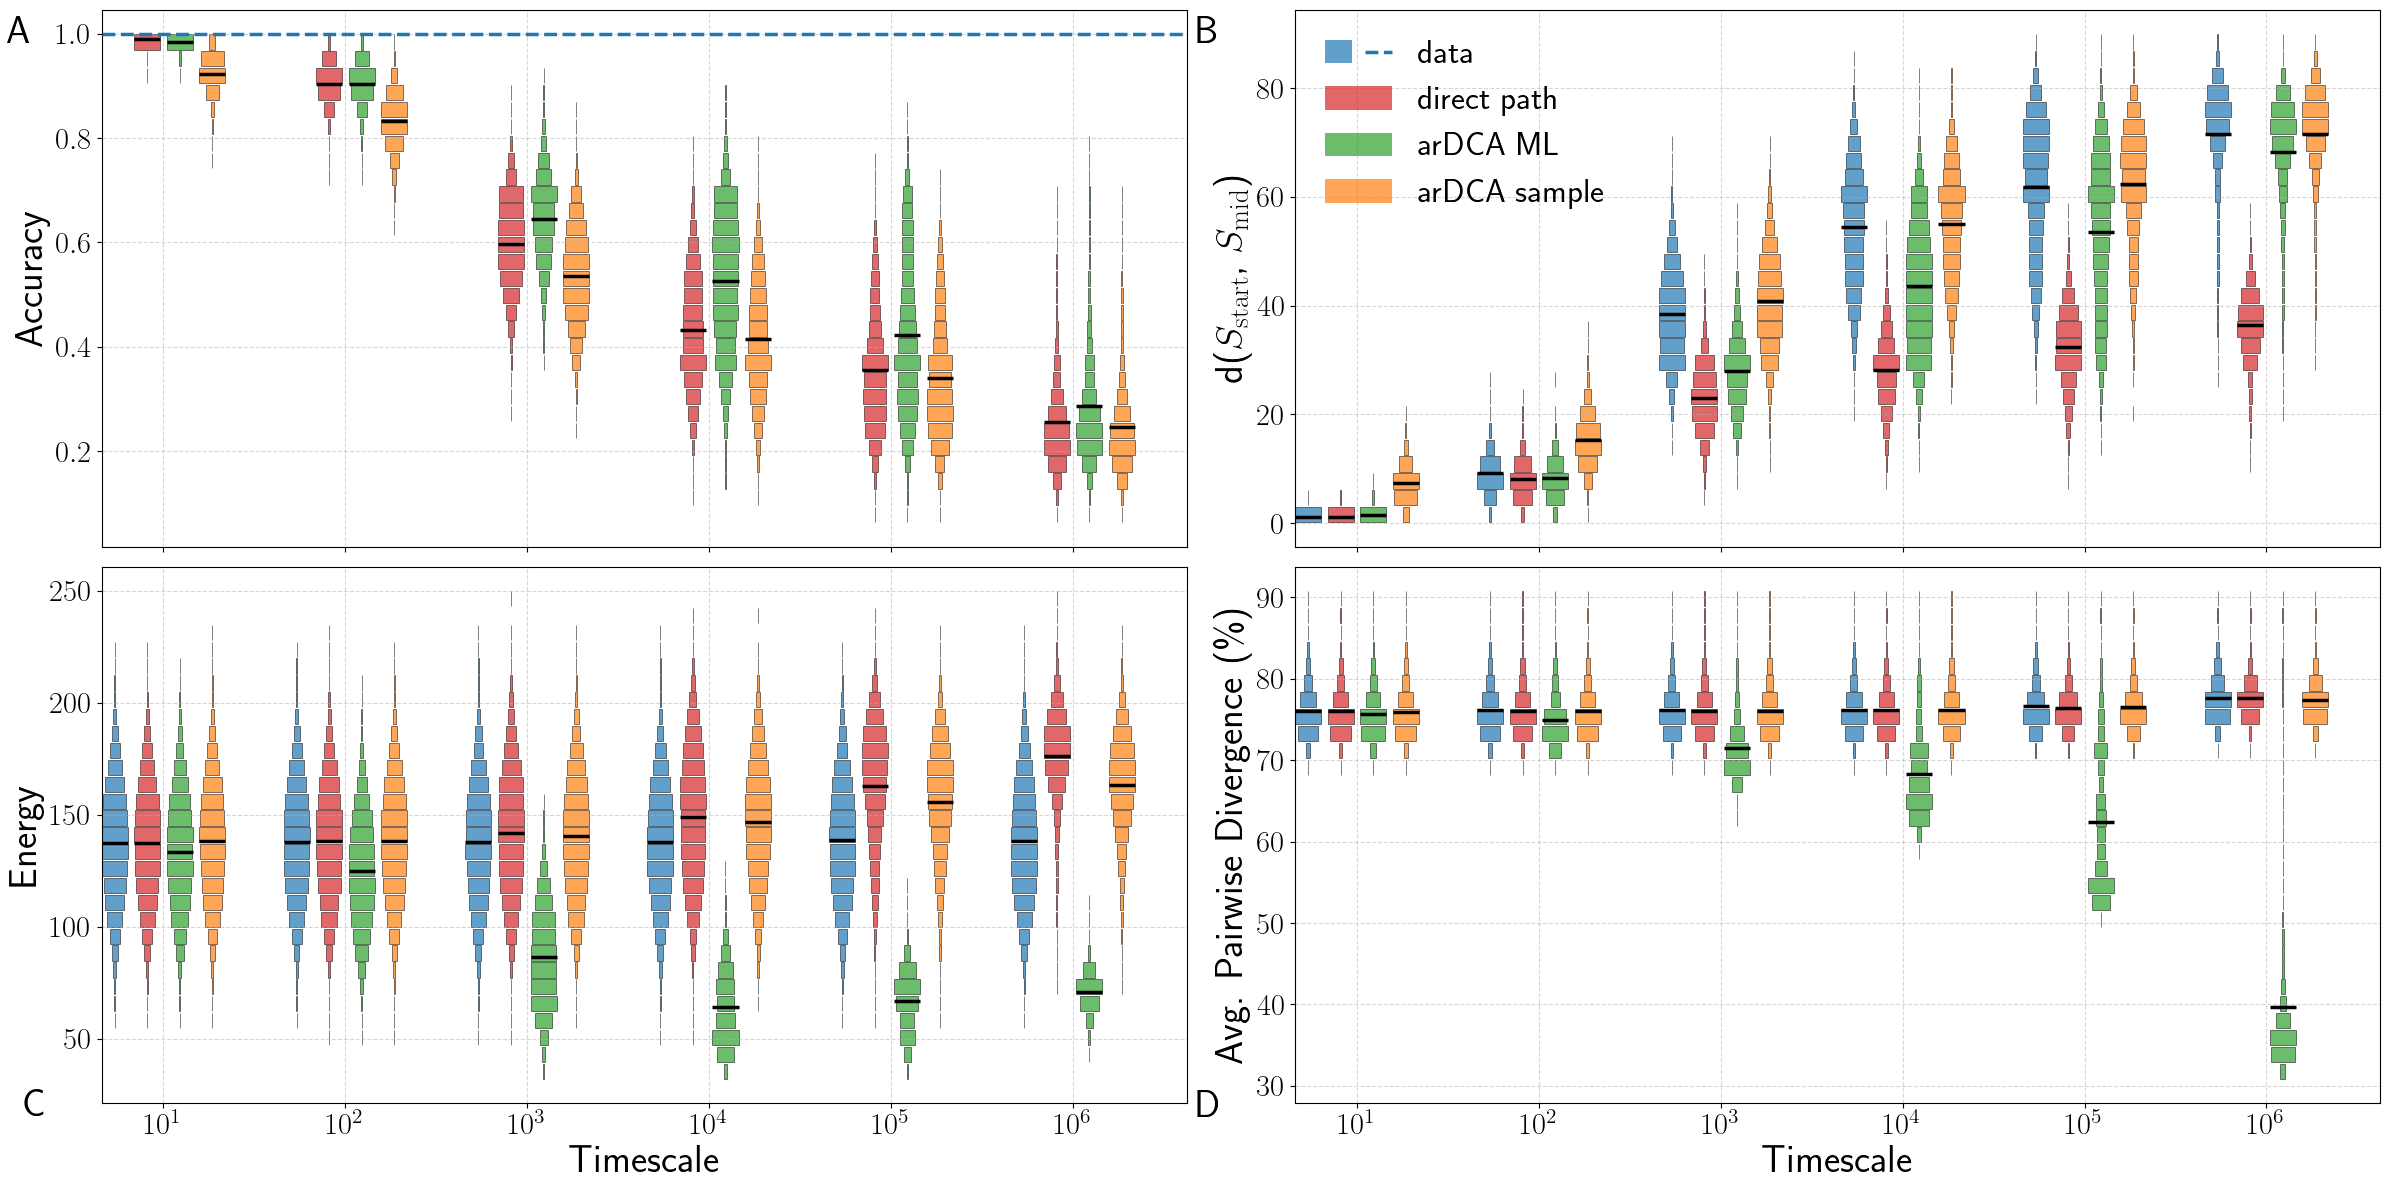

Figura combinata salvata in: ../immagini_paper/CM/patience5/compare_metrics/_rJ1e-3_rH1e-5_percentile0.5/combined_metrics_summary.pdf


In [104]:
# Combined figure with the 4 required subplots (use_1cond = False case)
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from matplotlib.legend_handler import HandlerTuple

COMMON_LABEL_FONTSIZE = 28
COMMON_TICK_FONTSIZE = 22
COMMON_LEGEND_FONTSIZE = 24
COMMON_GRID_ALPHA = 0.5
COMMON_MEAN_LINEWIDTH = 2.5
COMMON_BAR_LINEWIDTH = 0.5
COMMON_GRID_LINESTYLE = '--'
COMMON_GRID_LINEWIDTH = 0.8

# Main parameter: horizontal distance between two adjacent histogram groups
# (groups corresponding to different x positions: data/direct/ML/sample).
GROUP_SPACING = 0.95

# Parameter: horizontal gap between left-column and right-column subplots.
# Increase to further separate the left subplots from the right ones.
SUBPLOT_COLUMN_GAP = 0.1

palette = sns.color_palette("tab10")
combined_colors = {
    'data': palette[0],
    'arDCA sample': palette[1],
    'direct path': palette[3],
    'arDCA ML': palette[2],
}

def format_timescale_labels(timescales):
    labels = []
    for t in timescales:
        if 'x10e' in t:
            exponent = t.split('x10e')[1]
            labels.append(f'$10^{{{exponent}}}$')
        elif '10e' in t:
            exponent = t.split('10e')[1]
            labels.append(f'$10^{{{exponent}}}$')
        else:
            labels.append(t)
    return labels

METHOD_ORDER = ['data', 'direct path', 'arDCA ML', 'arDCA sample']
LEFT_METHOD_SLOT_WIDTH = 0.17
RIGHT_METHOD_SLOT_WIDTH = 0.17

def get_method_offsets(slot_width, method_order=METHOD_ORDER):
    return {
        label: (idx - (len(method_order) - 1) / 2) * slot_width
        for idx, label in enumerate(method_order)
    }

def plot_shifted_histograms(ax, timescales, series_by_label, labels, colors, positions, width, bins, method_order=METHOD_ORDER, method_offsets=None):
    if method_offsets is None:
        method_offsets = get_method_offsets(width, method_order)

    for i, t in enumerate(timescales):

        for label in labels:
            data_vals = np.asarray(series_by_label[label][t])
            counts, bin_edges = np.histogram(data_vals, bins=bins, density=False)
            max_count = counts.max()
            counts_normalized = counts / max_count * width * 0.8 if max_count > 0 else np.zeros_like(counts)
            offset = method_offsets[label]
            bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

            for bc, cn in zip(bin_centers, counts_normalized):
                if cn > 0:
                    ax.barh(
                        bc,
                        cn,
                        height=(bin_edges[1] - bin_edges[0]) * 0.9,
                        left=positions[i] + offset - cn / 2,
                        color=colors[label],
                        alpha=0.7,
                        edgecolor='black',
                        linewidth=COMMON_BAR_LINEWIDTH,
                    )

            mean_val = data_vals.mean()
            ax.hlines(
                mean_val,
                positions[i] + offset - width * 0.4,
                positions[i] + offset + width * 0.4,
                colors='black',
                linewidth=COMMON_MEAN_LINEWIDTH,
                zorder=10,
            )

def style_axis(ax, positions, xlabels, ylabel, show_xlabel=True, grid=True):
    ax.set_xticks(positions)
    ax.set_xticklabels(xlabels, fontsize=COMMON_TICK_FONTSIZE)
    if show_xlabel:
        ax.set_xlabel('Timescale', fontsize=COMMON_LABEL_FONTSIZE)
    ax.set_ylabel(ylabel, fontsize=COMMON_LABEL_FONTSIZE)
    ax.tick_params(axis='y', labelsize=COMMON_TICK_FONTSIZE)
    if grid:
        ax.grid(
            True,
            which='major',
            axis='both',
            alpha=COMMON_GRID_ALPHA,
            linestyle=COMMON_GRID_LINESTYLE,
            linewidth=COMMON_GRID_LINEWIDTH,
        )

def add_panel_label(ax, label, x, y, ha, va):
    txt = ax.text(
        x,
        y,
        label,
        transform=ax.transAxes,
        ha=ha,
        va=va,
        fontsize=COMMON_LABEL_FONTSIZE,
        fontweight='bold',
        clip_on=False,
    )
    txt.set_in_layout(False)

xlabels = format_timescale_labels(timescales)
fig, axes = plt.subplots(2, 2, figsize=(24, 12), sharex=True)
ax_accuracy, ax_distance, ax_energy, ax_divergence = axes.flatten()

# Shared parameters for the left column (better alignment between the two subplots)
left_positions = np.arange(len(timescales)) * GROUP_SPACING
left_width = LEFT_METHOD_SLOT_WIDTH
left_method_offsets_4 = get_method_offsets(left_width, METHOD_ORDER)

# 1) accuracy histogram
positions_acc = left_positions
width_acc = left_width
accuracy_labels = ['direct path', 'arDCA ML', 'arDCA sample']
accuracy_series = {
    'direct path': {t: acc_naive[t].cpu().numpy() for t in timescales},
    'arDCA ML': {t: acc_mdlML[t].cpu().numpy() for t in timescales},
    'arDCA sample': {t: acc_mdl[t].cpu().numpy() for t in timescales},
}
all_accuracy_values = []
for t in timescales:
    all_accuracy_values.extend(accuracy_series['direct path'][t])
    all_accuracy_values.extend(accuracy_series['arDCA ML'][t])
    all_accuracy_values.extend(accuracy_series['arDCA sample'][t])
bins_accuracy = np.linspace(min(all_accuracy_values), max(all_accuracy_values), 30)

# In the accuracy subplot the 'data' column is empty, but direct/ML/sample
# use the same column positions as in the energy subplot.
accuracy_method_offsets = {
    label: left_method_offsets_4[label]
    for label in accuracy_labels
}

plot_shifted_histograms(
    ax_accuracy,
    timescales,
    accuracy_series,
    accuracy_labels,
    combined_colors,
    positions_acc,
    width_acc,
    bins_accuracy,
    method_offsets=accuracy_method_offsets,
)
ax_accuracy.axhline(
    y=1,
    color=combined_colors['data'],
    linewidth=COMMON_MEAN_LINEWIDTH,
    linestyle='--',
    zorder=5,
)
style_axis(ax_accuracy, positions_acc, xlabels, 'Accuracy', show_xlabel=False)

legend_handles = [
    (
        Patch(facecolor=combined_colors['data'], edgecolor='none', alpha=0.7),
        Line2D([0], [0], color=combined_colors['data'], linestyle='--', linewidth=COMMON_MEAN_LINEWIDTH),
    ),
    Patch(facecolor=combined_colors['direct path'], edgecolor='none', label='direct path', alpha=0.7),
    Patch(facecolor=combined_colors['arDCA ML'], edgecolor='none', label='arDCA ML', alpha=0.7),
    Patch(facecolor=combined_colors['arDCA sample'], edgecolor='none', label='arDCA sample', alpha=0.7),
]
legend_labels = ['data', 'direct path', 'arDCA ML', 'arDCA sample']

# Shared parameters for the right column (alignment between distance and divergence)
right_positions = np.arange(len(timescales)) * GROUP_SPACING
right_width = RIGHT_METHOD_SLOT_WIDTH
right_method_offsets = get_method_offsets(right_width, METHOD_ORDER)

# 2) start-to-mid distance histograms
positions_distance = right_positions
width_distance = right_width
distance_labels = ['data', 'direct path', 'arDCA ML', 'arDCA sample']
distance_series = {
    'data': {t: distance_data[t][:, 0].cpu().numpy() for t in timescales},
    'direct path': {t: distance_naive[t][:, 0].cpu().numpy() for t in timescales},
    'arDCA ML': {t: distance_mdl_ML[t][:, 0].cpu().numpy() for t in timescales},
    'arDCA sample': {t: distance_mdl[t][:, 0].cpu().numpy() for t in timescales},
}
all_distance_values = np.concatenate([distance_series['data'][t] for t in timescales])
bins_distance = np.linspace(all_distance_values.min(), all_distance_values.max(), 30)
plot_shifted_histograms(
    ax_distance,
    timescales,
    distance_series,
    distance_labels,
    combined_colors,
    positions_distance,
    width_distance,
    bins_distance,
    method_offsets=right_method_offsets,
)
style_axis(ax_distance, positions_distance, xlabels, r'd($S_\mathrm{start}$, $S_\mathrm{mid}$)', show_xlabel=False)
ax_distance.legend(
    handles=legend_handles,
    labels=legend_labels,
    loc='upper left',
    fontsize=COMMON_LEGEND_FONTSIZE,
    frameon=False,
    handler_map={tuple: HandlerTuple(ndivide=None)},
)

# 3) energy histograms
positions_energy = left_positions
width_energy = left_width
energy_labels = ['data', 'direct path', 'arDCA ML', 'arDCA sample']
energy_series = {
    'data': {t: energies_data[t].cpu().numpy() for t in timescales},
    'direct path': {t: energies_naive[t].cpu().numpy() for t in timescales},
    'arDCA ML': {t: energies_ML[t].cpu().numpy() for t in timescales},
    'arDCA sample': {t: energies_model[t].cpu().numpy() for t in timescales},
}
all_energy_values = []
for t in timescales:
    for label in energy_labels:
        all_energy_values.extend(energy_series[label][t])
bins_energy = np.linspace(min(all_energy_values), max(all_energy_values), 30)
plot_shifted_histograms(
    ax_energy,
    timescales,
    energy_series,
    energy_labels,
    combined_colors,
    positions_energy,
    width_energy,
    bins_energy,
    method_offsets=left_method_offsets_4,
)
style_axis(ax_energy, positions_energy, xlabels, 'Energy')

# 4) intra-dataset pairwise divergence distributions
positions_divergence = right_positions
width_divergence = right_width
divergence_labels = ['data', 'direct path', 'arDCA ML', 'arDCA sample']
divergence_series = {
    label: {t: distance_distributions[label][t] * 100 for t in timescales}
    for label in divergence_labels
}
all_divergence_values = []
for t in timescales:
    for label in divergence_labels:
        all_divergence_values.extend(divergence_series[label][t].tolist())
bins_divergence = np.linspace(min(all_divergence_values), max(all_divergence_values), 30)
plot_shifted_histograms(
    ax_divergence,
    timescales,
    divergence_series,
    divergence_labels,
    combined_colors,
    positions_divergence,
    width_divergence,
    bins_divergence,
    method_offsets=right_method_offsets,
)
style_axis(ax_divergence, positions_divergence, xlabels, 'Avg. Pairwise Divergence (\%)')

# Panel labels at the four outer corners
add_panel_label(ax_accuracy, 'A', x=-0.065, y=0.925, ha='right', va='bottom')
add_panel_label(ax_distance, 'B',  x=-0.09, y=0.925, ha='left', va='bottom')
add_panel_label(ax_energy, 'C', x=-0.05, y=0.025, ha='right', va='top')
add_panel_label(ax_divergence, 'D', x=-0.09, y=0.025, ha='left', va='top')

combined_output_path = output_path + 'combined_metrics_summary.pdf'
fig.tight_layout()
fig.subplots_adjust(wspace=SUBPLOT_COLUMN_GAP)
fig.savefig(combined_output_path, dpi=300, bbox_inches='tight')
plt.show()

print("Figura combinata salvata in:", combined_output_path)
